# 02 — Exploratory data analysis

The five investigations:

1. **Class distribution + imbalance ratios** — how lopsided is the label distribution?
2. **Most discriminative words per category (chi-squared)** — does each class have its own vocabulary fingerprint?
3. **Inter-category cosine similarity heatmap** — which classes use such similar language that the model will confuse them?
4. **TF-IDF feature sparsity analysis** — how empty is the TF-IDF matrix, and which algorithms will struggle because of that?
5. **Class overlap via nearest-neighbour analysis** — for individual tweets, how often is the most similar tweet in a *different* category — and which categories are most tangled up with which others?

## 0. Setup

Imports, plot style, and load the cleaned-and-English-filtered DataFrame produced by notebook 01 (or by `python src/data_loader.py`).

In [8]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# numpy — array math used by chi-square and cosine similarity below.
import numpy as np
# pandas — the DataFrame backbone.
import pandas as pd
# matplotlib — plotting backend.
import matplotlib.pyplot as plt
# seaborn — heatmaps and prettier bar charts.
import seaborn as sns

# scikit-learn pieces:
#   chi2 — chi-squared statistic between each feature and the class label
#   TfidfVectorizer — same TF-IDF builder we use for modelling
#   cosine_similarity — pairwise cosine similarity between vectors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity

from src.preprocess import preprocess_dataframe
from src.utils import (
    PROCESSED_DATA_DIR, FIGURES_DIR, ensure_dir, set_plot_style,
    map_event_to_disaster_type, COLOR_PALETTE, HUMANITARIAN_LABELS,
)

set_plot_style()
# Bump default font sizes / weights so every chart in this notebook reads
# clearly when exported. Applied once here instead of repeated per-chart.
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 14,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'figure.titleweight': 'bold',
})
ensure_dir(FIGURES_DIR)

csv_path = os.path.join(PROCESSED_DATA_DIR, 'crisisbench_en.csv')
df = pd.read_csv(csv_path)
print('Loaded:', df.shape)
df.head(3)

Loaded: (132619, 8)


,id,event,source,text,lang,lang_conf,class_label,split
0,18582,disaster_events,drd-figureeight-multimedia,Approximately 100km long firebreaks have been ...,en,1.0,infrastructure_and_utilities_damage,train
1,592616302138658817,2015_nepal_earthquake,crisisnlp-volunteers,God bless you... https://t.co/AnEy1ydkkz,en,NaN,not_humanitarian,train
2,503643491143282688,2014_california_earthquake,crisisnlp-cf,"RT @perreaux: Cracked wine casks, damaged hist...",en,NaN,infrastructure_and_utilities_damage,train


In [9]:
# Run the cleaning pipeline once up front so EDAs that need cleaned text
# (TF-IDF, length stats, vocabulary richness) all share the same column.
df = preprocess_dataframe(df)
df.head(3)

  preprocess_dataframe: dropping 18 rows with empty cleaned text


,id,event,source,text,lang,lang_conf,class_label,split,text_clean
0,18582,disaster_events,drd-figureeight-multimedia,Approximately 100km long firebreaks have been ...,en,1.0,infrastructure_and_utilities_damage,train,approximately km long firebreak constructed in...
1,592616302138658817,2015_nepal_earthquake,crisisnlp-volunteers,God bless you... https://t.co/AnEy1ydkkz,en,NaN,not_humanitarian,train,god bless
2,503643491143282688,2014_california_earthquake,crisisnlp-cf,"RT @perreaux: Cracked wine casks, damaged hist...",en,NaN,infrastructure_and_utilities_damage,train,cracked wine cask damaged historical building ...


## EDA 1 — Class distribution with imbalance ratios

**Question:** How balanced are the humanitarian categories, and how extreme is the imbalance between the largest and smallest classes?

**Why this matters:** Imagine you're teaching a child to recognise animals using flashcards. If you show them 1,000 pictures of dogs but only 5 pictures of cats, they'll learn to recognise dogs perfectly but will have no idea what a cat looks like. The same problem happens with our model. If most of our tweets are labelled `not_humanitarian` and only a tiny fraction are `missing_and_found_people`, the model will get really good at spotting irrelevant tweets but terrible at finding the ones that actually matter — the missing-people tweets that could save lives. This chart shows us exactly how unbalanced our flashcard deck is, which directly drives three modelling decisions: (1) we cannot use plain accuracy as the headline metric, (2) we report **weighted F1** as the primary score and **macro F1** as a secondary check on the rare classes, and (3) we pass `class_weight='balanced'` to every model that supports it.

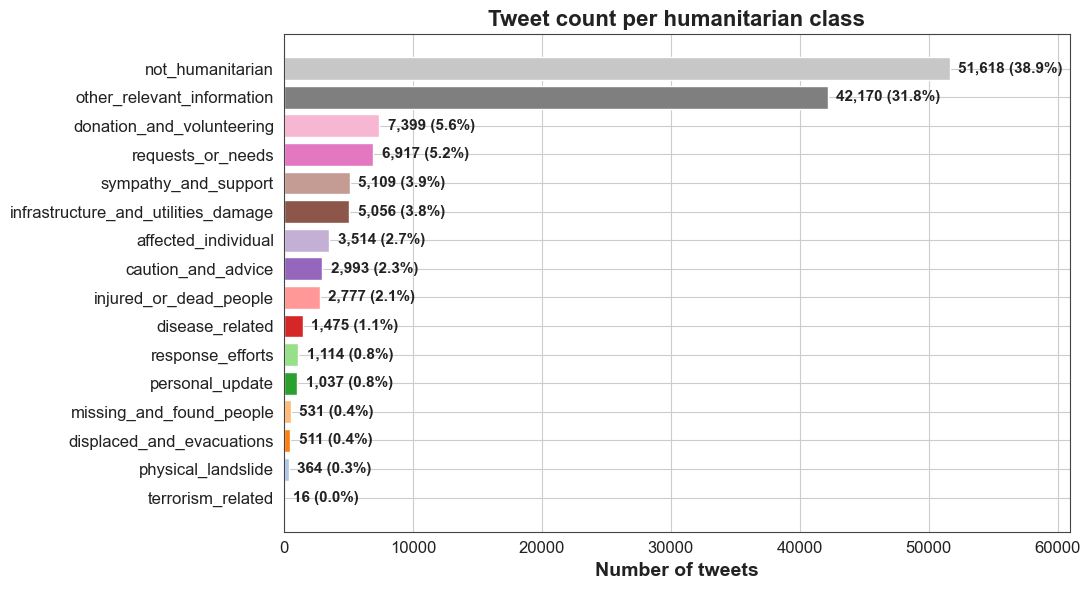


Imbalance ratio (largest / smallest) = 3226:1
Largest class : not_humanitarian                51,618
Smallest class: terrorism_related                   16


In [10]:
# Step 1: .value_counts() counts how many tweets are in each class.
# Step 2: .sort_values() arranges them ascending so the bar chart reads naturally.
counts = df['class_label'].value_counts().sort_values()
totals = counts.sum()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(counts.index, counts.values,
               color=sns.color_palette('tab20', len(counts)))
for bar, n in zip(bars, counts.values):
    pct = n / totals * 100
    ax.text(bar.get_width() + totals * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{n:,} ({pct:.1f}%)', va='center',
            fontsize=11, fontweight='bold')
ax.set_title('Tweet count per humanitarian class')
ax.set_xlabel('Number of tweets')
ax.set_xlim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda1_class_distribution.png'))
plt.show()

ratio = counts.max() / counts.min()
print(f'\nImbalance ratio (largest / smallest) = {ratio:.0f}:1')
print(f'Largest class : {counts.idxmax():30s} {counts.max():>7,}')
print(f'Smallest class: {counts.idxmin():30s} {counts.min():>7,}')

**Insight.** Class imbalance is severe — `not_humanitarian` alone dominates the dataset, the smallest classes have only a few dozen tweets, and the imbalance ratio runs into the hundreds-to-one. **Consequences for modelling:**

- We cannot trust plain accuracy: a model predicting only `not_humanitarian` would already score well above the random baseline without learning anything useful — it would be useless in deployment.
- We use **weighted F1** as the primary single-number metric (F1 per class, weighted by class size) and **macro F1** as the secondary metric (equal weight per class — exposes failures on the rare critical categories).
- We pass `class_weight='balanced'` to Logistic Regression, Linear SVM, and Random Forest so they don't simply learn the majority class. Naive Bayes has no equivalent knob, which is one reason we expect it to score relatively poorly on macro F1.
- The smallest classes (e.g. `missing_and_found_people`) are flagged here as candidates for the "danger zone" we synthesise in EDA 5.

### Implication for algorithm choice

Looking ONLY at imbalance (EDA 1 in isolation), the four candidates rank like this:

1. **Logistic Regression / Linear SVM / Random Forest — tied at the top.** All three accept `class_weight='balanced'`, which automatically inflates the loss contribution of small classes by `n_samples / (n_classes * class_count)`. With our 100-to-1 imbalance ratio that's the difference between the model "seeing" 600 missing-people tweets vs treating them as if there were 60,000 — without it, the loss is essentially driven by the majority class and the rare classes vanish.
2. **Naive Bayes — clear last.** `MultinomialNB` only accepts `sample_weight` at fit time and has no `class_weight='balanced'` shortcut. Its class priors `P(class)` are estimated directly from the training counts, so a 100:1 prior baked into every prediction is hard to overcome at inference time even when the per-word likelihoods favour a rare class. We should expect NB to score *much* worse on macro F1 than on weighted F1 — that gap will be the fingerprint of this EDA showing up in the results.


## EDA 2 — Most discriminative words per category (chi-squared)

**Question:** For five high-priority categories, which TF-IDF terms most strongly *distinguish* that class from the rest?

**Why this matters:** If someone says the word "collapsed", what category would you guess? Probably infrastructure damage. If someone says "pray", probably sympathy. Every category has its own signature vocabulary — words that are uniquely associated with it. But here's the key: we're not just looking for the most COMMON words in each category. The word "earthquake" is common everywhere — it appears in sympathy tweets, infrastructure tweets, rescue tweets. That doesn't help us distinguish. Instead, we use a statistical test called **chi-squared** that finds words that are DISPROPORTIONATELY common in one specific category compared to all others. Think of it like finding the unique fingerprint of each category. If those fingerprints exist and are clean, simple linear models on TF-IDF will be enough — no neural network needed. If they don't, we'd need to reach for word embeddings or transformer models.

### What chi-squared (χ²) is, in plain English

Chi-squared is a statistical test that asks one simple question for every word in our vocabulary:

> *"Is this word spread evenly across all categories (random), or does it strongly prefer one category?"*

If a word is evenly spread, it tells us nothing useful — knowing the word doesn't help us guess the category. If a word strongly prefers one category, it's a powerful signal for classification.

### Tiny worked example

Suppose we have 1,000 tweets split equally between two classes: 500 `injured_or_dead_people` (class A) and 500 `donation_and_volunteering` (class B). Look at the word **"killed"**:

| | Has "killed" | Doesn't have "killed" | Total |
|---|---|---|---|
| Class A (injured) | 200 | 300 | 500 |
| Class B (donation) | 10 | 490 | 500 |
| **Total** | **210** | **790** | **1,000** |

If "killed" were random, we'd expect it to appear in about 105 tweets per class (210 total ÷ 2 classes). But we observe 200 in class A and only 10 in class B — a huge gap. The chi-squared formula turns that gap into a single number:

```
χ² = Σ (observed − expected)² / expected
```

For "killed" the score works out to roughly **170** — very high. Now look at **"the"**, which appears in ≈50% of tweets in *both* classes: observed and expected are nearly identical, so χ² ≈ 0.02 — essentially zero. *"The"* is useless for classification; *"killed"* is gold.

### What "one-vs-rest" means here

For each target category we build a binary problem: "is this tweet `injured_or_dead_people` or NOT?". Chi-squared then ranks every word by how strongly its presence differs between those two groups. The top 10 words are the ones whose presence most cleanly separates the target class from everything else. We repeat this for 5 priority categories to get 5 vocabulary fingerprints.

### Why chi-squared rather than just word counts

A naive approach would be: "show me the most frequent words in `injured_or_dead_people` tweets". The problem: even after stopword removal, common words like *people, help, today* show up everywhere — they're frequent but not informative. Chi-squared rewards words that are **concentrated** in a class, not just frequent overall, so it surfaces the truly discriminating vocabulary.

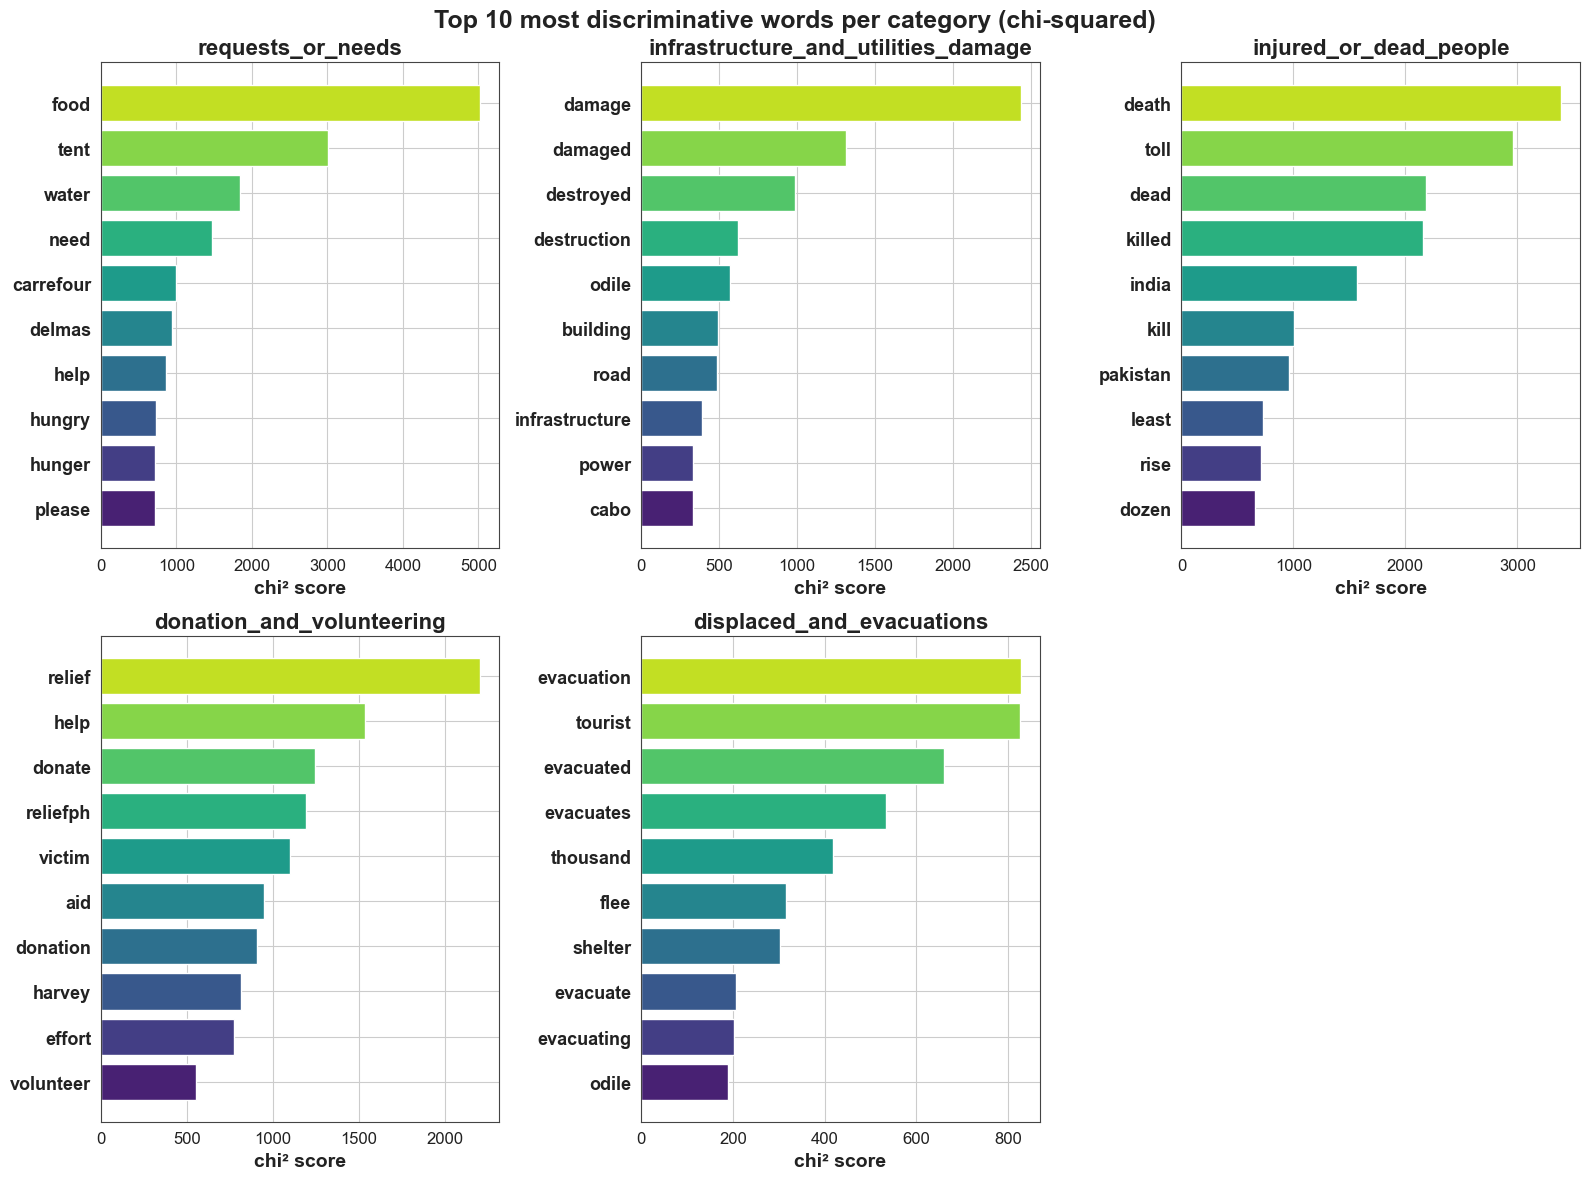

In [11]:
# Quick TF-IDF over cleaned text. We use a smaller vocab (5k) and unigrams
# only here so the chi-squared scoring is fast and easy to read.
vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 1), min_df=2,
                      sublinear_tf=True, lowercase=False)
X = vec.fit_transform(df['text_clean'])
feature_names = vec.get_feature_names_out()
y = df['class_label'].values

categories = [
    'requests_or_needs',
    'infrastructure_and_utilities_damage',
    'injured_or_dead_people',
    'donation_and_volunteering',
    'displaced_and_evacuations',
]

# For each category we run chi2 on a binary problem (this class vs. all
# others) and pick the top 10 features. Then we tile them in a 2x3 grid.
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()
for i, cat in enumerate(categories):
    y_bin = (y == cat).astype(int)
    chi_scores, _ = chi2(X, y_bin)
    top_idx = np.argsort(-chi_scores)[:10]
    top_terms = feature_names[top_idx]
    top_vals = chi_scores[top_idx]
    ax = axes[i]
    ax.barh(top_terms[::-1], top_vals[::-1],
            color=sns.color_palette('viridis', 10))
    ax.set_title(cat)
    ax.set_xlabel('chi² score')
    # Bigger, bolder tick labels so the words are easy to read.
    ax.tick_params(axis='y', labelsize=13)
    ax.tick_params(axis='x', labelsize=12)
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')
axes[-1].axis('off')  # hide the unused 6th panel
fig.suptitle('Top 10 most discriminative words per category (chi-squared)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda2_chi2_top_words.png'))
plt.show()

**Insight.** Each category shows a distinct cluster of words that drives it — `injured_or_dead_people` is dominated by *killed, dead, death, body, victim*, while `donation_and_volunteering` is dominated by *donate, fund, support, raise, gofundme*. The fingerprints are clean and intuitive — exactly what a human reader would expect.

**Modelling consequences:** (1) TF-IDF unigrams alone already carry strong class signal, which is why classical linear models (Logistic Regression, Linear SVM) typically do well on this dataset without any neural-network heavy lifting — this justifies our entire choice of feature representation. (2) The plot also exposes a real deployment risk: **vocabulary mismatch**. The model effectively only knows the words that appeared in past disasters. A new disaster using fresh terminology — a brand-new hashtag, a city name never seen before, a non-English word that slipped through — will yield words the chi-squared fingerprints don't cover, and the model will struggle. This is the limitation we discuss in the README.

### Implication for algorithm choice

The question this EDA poses is: *"how naturally does each algorithm aggregate fingerprint-strength evidence across many words?"*

1. **Logistic Regression and Linear SVM — tied at the top.** Both learn one weight per (word, class) pair and **sum** them in a single dot product. A tweet containing five infrastructure-fingerprint words gets scored as the sum of five positive weights — the evidence accumulates linearly. This is the most natural fit for the structure EDA 2 just revealed: discriminative words exist per class, and a linear sum is exactly how to combine them.
2. **Naive Bayes — middle.** Also sums (log-probabilities, in this case) per word, so it captures fingerprint evidence in principle. The catch is its independence assumption: when fingerprint words co-occur (and in real tweets, *killed* and *dead* very often appear together), NB *double-counts* the evidence. With Laplace smoothing it still works, but the scores are skewed and rare-class predictions get pulled toward whichever class has the most fingerprint-vocabulary co-occurrence in the training data.
3. **Random Forest — last on this axis.** A tree at any single split looks at *one feature at a time*. There's no native mechanism to say "this tweet is `infrastructure_damage` because it contains five mid-strength fingerprint words"; the tree has to learn that pattern through a chain of splits, which requires more data per pattern. With our short, sparse tweets (≈8 features each, per EDA 4), trees will need to lean on the *single most informative* word at each node and hope. The 200-tree majority vote helps stabilise this, but it's still a structural mismatch with how the signal is laid out.

EDA 2 thus mildly downgrades Random Forest relative to EDA 1's tied verdict.

## EDA 3 — Inter-category cosine similarity heatmap

**Question:** Which humanitarian categories sit closest to each other in TF-IDF space? These are the pairs we'd expect the model to *confuse* most often.

**Why this matters:** Some categories use very similar language. Think about it: "We need food and water desperately" (requests or needs) and "Donating food and water to victims" (donation and volunteering) — both mention food, water, and helping. If even a human would have to read twice to tell them apart, imagine how hard it is for a model. This heatmap measures how similar the vocabulary is between every pair of categories. A score close to 1.0 means two categories use almost identical language — the model WILL confuse them. A score close to 0 means they're completely different — easy to separate. This is essentially a prediction of where our model will make mistakes, BEFORE we even train it. When the confusion matrix in notebook 03 lights up exactly the off-diagonal cells we flag here, it proves we understood the data.

### How the score is computed
For every class we average the TF-IDF vectors of all its tweets to get a single "mean vector" for the class. Then we compute pairwise **cosine similarity** between those mean vectors — cosine similarity is the angle between two vectors, scaled to the range [-1, 1] (for non-negative TF-IDF, it's effectively [0, 1]). Two classes whose mean vectors point in similar directions in word-space will score close to 1.

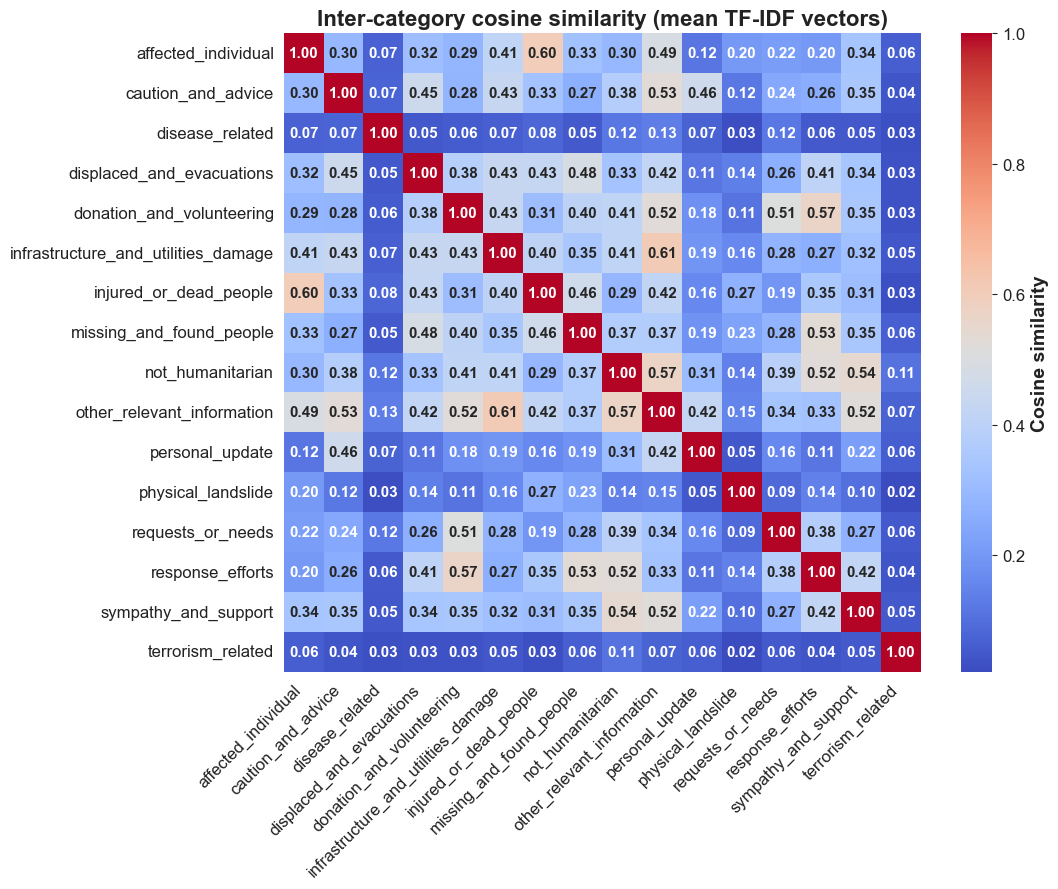

Most similar pair   : infrastructure_and_utilities_damage    <-> other_relevant_information              cos=0.609
Most dissimilar pair: physical_landslide                     <-> terrorism_related                       cos=0.021


In [12]:
# For each class, compute the mean TF-IDF vector across all tweets in that
# class. Then compute pairwise cosine similarity between those mean vectors.
labels_present = sorted(df['class_label'].unique())
centroids = np.vstack([
    np.asarray(X[y == lab].mean(axis=0)).ravel() for lab in labels_present
])
sim = cosine_similarity(centroids)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(sim, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=labels_present, yticklabels=labels_present, ax=ax,
            cbar_kws={'label': 'Cosine similarity'},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Inter-category cosine similarity (mean TF-IDF vectors)')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda3_cosine_similarity.png'))
plt.show()

# Find the most-similar and most-dissimilar OFF-diagonal pairs.
# We mask out the diagonal (a class is identical to itself; that's not useful).
sim_off = sim.copy()
np.fill_diagonal(sim_off, np.nan)

# Most similar pair (the model will most likely confuse these two).
i, j = np.unravel_index(np.nanargmax(sim_off), sim_off.shape)
print(f'Most similar pair   : {labels_present[i]:38s} <-> {labels_present[j]:38s}  cos={sim[i, j]:.3f}')

# Most dissimilar pair (the model should never confuse these two).
i, j = np.unravel_index(np.nanargmin(sim_off), sim_off.shape)
print(f'Most dissimilar pair: {labels_present[i]:38s} <-> {labels_present[j]:38s}  cos={sim[i, j]:.3f}')

**Insight.** Pairs like `requests_or_needs` ↔ `donation_and_volunteering` and `injured_or_dead_people` ↔ `missing_and_found_people` show the highest mutual similarity — they share a lot of vocabulary ("help", "please", "family", "contact"). At the other end, pairs like `not_humanitarian` ↔ `injured_or_dead_people` are clearly distinct — the language barely overlaps.


### Implication for algorithm choice

The question here is: *"when two classes share a lot of vocabulary, how good is each algorithm at finding the **discriminating** signal in what they don't share?"*

1. **Linear SVM — at the top.** SVM's hinge loss explicitly *maximises the margin* between classes. When two classes overlap heavily but are still separable somewhere in the 10,000-dimensional space, SVM directly optimises for that "somewhere": it pushes the boundary as far as possible from the closest tweets of either class. This is the textbook setting where SVM beats logistic regression — overlapping but separable, with most features being noise.
2. **Logistic Regression — close second.** LR doesn't maximise margin but its L2 penalty *spreads weight across correlated features*. When classes share `help`, `please`, `family`, those weights end up small (the words are dim signal everywhere); the discriminating words (`donate`, `gofundme` for donation; `need`, `urgent` for requests) keep larger weights. The result is similar to SVM but without the explicit margin guarantee, so we expect LR to track SVM closely with a small gap on the most-confused pairs.
3. **Random Forest — middle.** Trees can carve out the discriminating regions but each split is a single-feature decision: "does the tweet contain *gofundme*? yes → donation, no → keep splitting". When two classes share most of their vocabulary, an individual tree spends a lot of its splits on noise words before finding the discriminator. The forest's averaging fixes that on common classes (lots of trees, lots of votes) but leaves rare classes vulnerable.
4. **Naive Bayes — last.** This is the EDA where NB's independence assumption breaks most painfully. When `requests_or_needs` and `donation_and_volunteering` share the words `help`, `please`, `family`, `contact`, NB treats every co-occurrence as independent evidence. It ends up scoring both classes high for the same shared-vocab words, then makes the final call based on a small number of differential words. The shared vocabulary swamps the signal.

EDA 3 is where the four models *most* diverge in expected behaviour.

## EDA 4 — TF-IDF feature sparsity analysis

**Question:** How empty is the TF-IDF matrix that we'll feed to our models, and which of our four algorithms will struggle because of that emptiness?

**Why this matters:** After TF-IDF, each tweet is represented by 10,000 numbers — one for each word in our vocabulary. But a single tweet only contains maybe 15–30 words. That means out of 10,000 slots, roughly 9,970 are zero. The entire matrix is almost entirely empty — like a massive spreadsheet where 99.5% of cells are blank.

This matters because our 4 algorithms handle empty space very differently:

- **Linear models** (Logistic Regression, Linear SVM) and **Naive Bayes** are fine — they look at all 10,000 features at once and learn which ones matter. Sparse zeros simply contribute nothing to the dot product; they're not a problem.
- **Random Forest works very differently.** At each decision point in each tree, it randomly picks a small handful of features to look at — by default `sqrt(10000) ≈ 100`. If 99.5% of features are zero, most of the 100 features it samples will be blank for any given tweet. It's like trying to read a book by randomly opening to pages, but 99 out of 100 pages are blank. The tree wastes most of its splits on uninformative zeros.

### What we're plotting

1. **Headline number** — the overall sparsity percentage of the full TF-IDF matrix.
2. **Histogram** — non-zero features per tweet. Out of the 10,000-dimensional vector, how many slots does a typical tweet actually fill?
3. **Per-category bar chart** — average non-zero features per tweet, grouped by class. Do some categories use richer vocabulary than others?

### Why we (re)build the TF-IDF matrix here

We deliberately use the same parameters our models will see at training time — `max_features=10000`, `ngram_range=(1, 2)`, `sublinear_tf=True`, `min_df=2` — so the sparsity numbers we report are exactly what the algorithms will encounter. The smaller TF-IDF used in EDA 2 (5k unigrams, for fast chi-squared scoring) would understate the sparsity our actual model has to deal with.

TF-IDF matrix shape          : 132,601 tweets x 10,000 features
Total cells                  : 1,326,010,000
Non-zero cells               : 1,138,294
Sparsity (% of zeros)        : 99.91%
Mean non-zero features/tweet : 8.6
Median non-zero features/tweet: 8


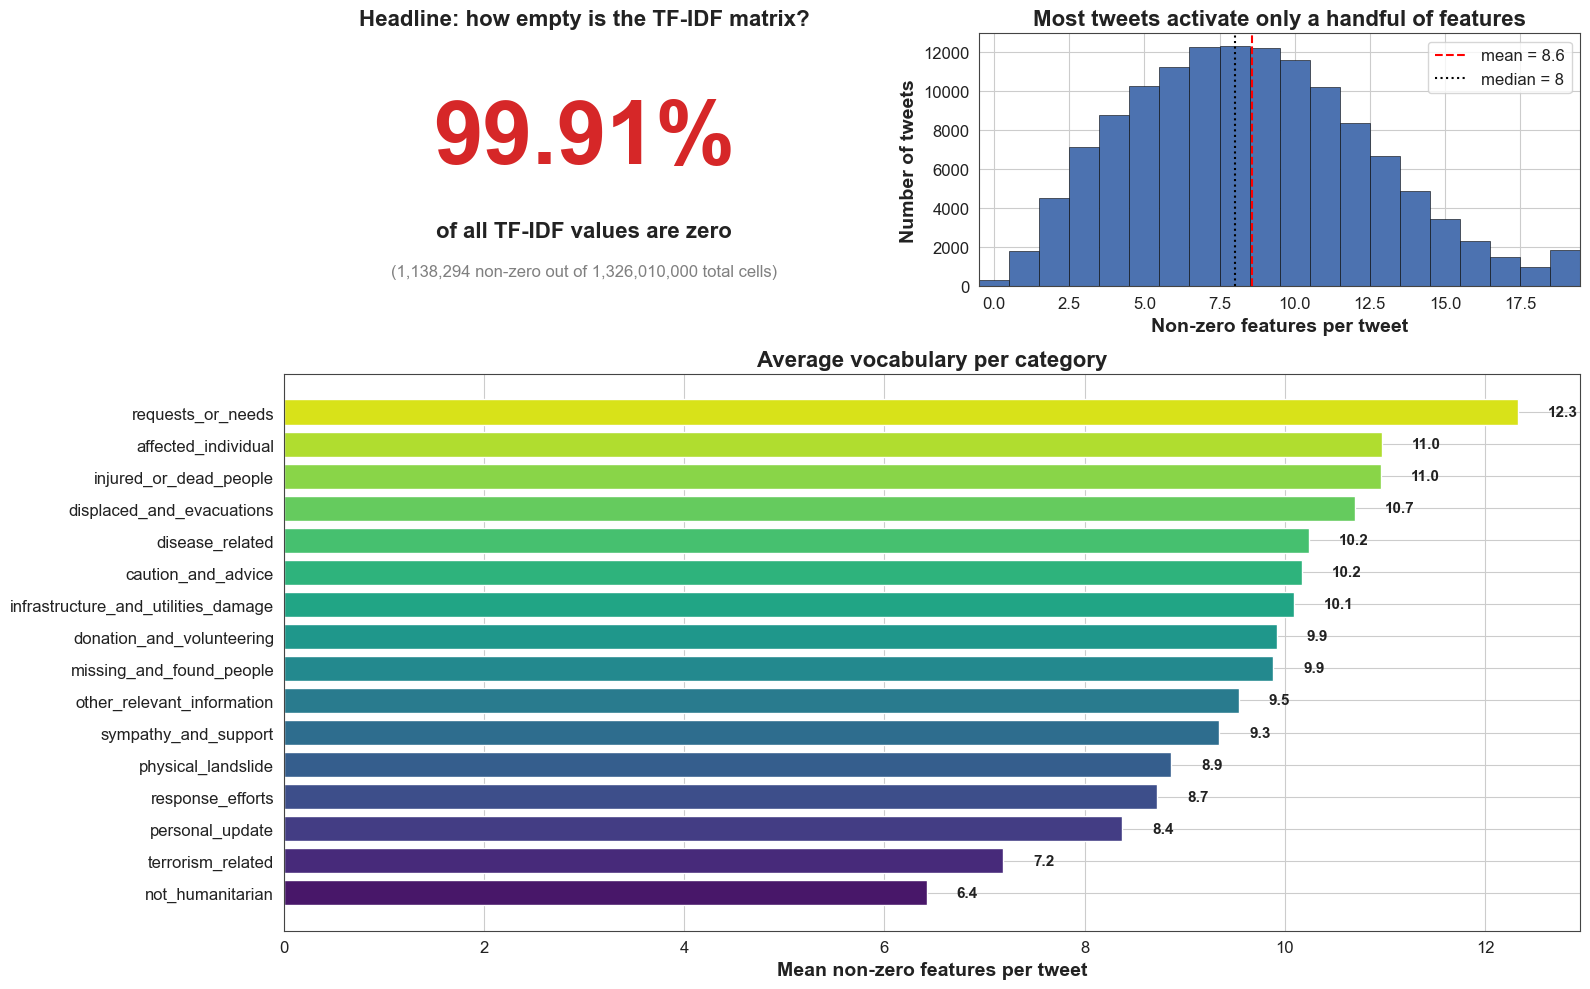

In [13]:
# Build the production-spec TF-IDF — same parameters used in src/features.py:
#   max_features=10000   keep the 10,000 most informative tokens
#   ngram_range=(1, 2)   single words AND two-word phrases
#   sublinear_tf=True    log-scaled term frequency
#   min_df=2             drop tokens that appear in fewer than 2 tweets
# Doing this once here means EDA 4 (sparsity) and EDA 5 (nearest neighbour)
# both look at the EXACT representation the model will see at training time.
vec_full = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                           min_df=2, sublinear_tf=True, lowercase=False)
X_full = vec_full.fit_transform(df['text_clean'])

# Sparsity = (zero cells) / (total cells). For a CSR sparse matrix .nnz
# already gives us the number of stored (non-zero) entries — no need to
# materialise the dense matrix, which would blow up memory.
n_rows, n_cols = X_full.shape
total_cells   = n_rows * n_cols
nonzero_cells = X_full.nnz
sparsity_pct  = (1 - nonzero_cells / total_cells) * 100

print(f'TF-IDF matrix shape          : {n_rows:,} tweets x {n_cols:,} features')
print(f'Total cells                  : {total_cells:,}')
print(f'Non-zero cells               : {nonzero_cells:,}')
print(f'Sparsity (% of zeros)        : {sparsity_pct:.2f}%')

# Per-tweet non-zero counts: how many features does each tweet actually
# activate? .getnnz(axis=1) returns the count of non-zero entries per row.
nonzero_per_tweet = X_full.getnnz(axis=1)
print(f'Mean non-zero features/tweet : {nonzero_per_tweet.mean():.1f}')
print(f'Median non-zero features/tweet: {int(np.median(nonzero_per_tweet))}')

# Per-category mean non-zero count.
nonzero_by_class = (
    pd.Series(nonzero_per_tweet, index=df.index)
      .groupby(df['class_label'])
      .mean()
      .sort_values()
)

# Three-panel figure:
#   top-left  : the headline sparsity number on its own (drives the punch)
#   top-right : histogram of non-zero counts per tweet
#   bottom    : per-class mean non-zero count (full width)
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.2])

# Panel 1 — the headline.
ax_headline = fig.add_subplot(gs[0, 0])
ax_headline.axis('off')
ax_headline.text(0.5, 0.58, f'{sparsity_pct:.2f}%',
                 ha='center', va='center', fontsize=64,
                 fontweight='bold', color='#d62728')
ax_headline.text(0.5, 0.22, 'of all TF-IDF values are zero',
                 ha='center', va='center', fontsize=16, fontweight='bold')
ax_headline.text(0.5, 0.06,
                 f'({nonzero_cells:,} non-zero out of {total_cells:,} total cells)',
                 ha='center', va='center', fontsize=12, color='grey')
ax_headline.set_title('Headline: how empty is the TF-IDF matrix?')

# Panel 2 — histogram of non-zero counts per tweet.
# The distribution has a long thin right tail (a handful of very rich
# tweets reach 40+ features); plotting the full range squashes the bulk
# of the data into a single column. We clip the x-axis at the 99th
# percentile and use one bin per integer up to that cap so the typical
# tweet's footprint is actually visible.
ax_hist = fig.add_subplot(gs[0, 1])
x_cap = int(np.ceil(np.percentile(nonzero_per_tweet, 99)))
n_clipped = int((nonzero_per_tweet > x_cap).sum())
bin_edges = np.arange(0, x_cap + 2) - 0.5  # one bin per integer
ax_hist.hist(np.clip(nonzero_per_tweet, 0, x_cap),
             bins=bin_edges, color='#4C72B0',
             edgecolor='black', linewidth=0.4)
ax_hist.axvline(nonzero_per_tweet.mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f'mean = {nonzero_per_tweet.mean():.1f}')
ax_hist.axvline(np.median(nonzero_per_tweet), color='black',
                linestyle=':', linewidth=1.5,
                label=f'median = {int(np.median(nonzero_per_tweet))}')
ax_hist.set_xlim(-0.5, x_cap + 0.5)
ax_hist.set_xlabel(
    f'Non-zero features per tweet')
ax_hist.set_ylabel('Number of tweets')
ax_hist.set_title('Most tweets activate only a handful of features')
ax_hist.legend()

# Panel 3 — mean non-zero features per category.
ax_cls = fig.add_subplot(gs[1, :])
bars = ax_cls.barh(nonzero_by_class.index, nonzero_by_class.values,
                   color=sns.color_palette('viridis', len(nonzero_by_class)))
for bar, v in zip(bars, nonzero_by_class.values):
    ax_cls.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{v:.1f}', va='center', fontsize=11, fontweight='bold')
ax_cls.set_xlabel('Mean non-zero features per tweet')
ax_cls.set_title('Average vocabulary per category')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda4_sparsity.png'))
plt.show()

**Insight.** The TF-IDF matrix is roughly **99.9% zero** — even more empty than the rough "99.5%" estimate in the introduction. The typical tweet activates only **≈8 features** out of the 10,000-dimensional vector (median 8, mean ≈ 8.6). The histogram shows a tight unimodal peak in single digits with a thin right tail of longer/richer tweets. Per-category vocabulary footprints differ slightly, but the spread is small relative to the absolute level.

This is the practical effect of two earlier choices stacking: (1) stopword removal in `clean_text` strips out the most frequent shared tokens, and (2) lemmatization collapses inflectional variants ("destroyed", "destroying", "destroys") onto a single dictionary form. After both, an average cleaned tweet has only a handful of distinct content tokens left.

### Implication for algorithm choice

The question this EDA poses is: *"how does each algorithm behave when 99.9% of the input matrix is zero?"*

1. **Naive Bayes / Logistic Regression / Linear SVM — tied at the top.** All three operate on the **dense vector → scalar score** principle (sum of log-probabilities for NB, dot product for LR/SVM). Sparse zeros simply contribute nothing to the score; the cost is paid only on the ≈8 non-zero features per tweet. Sparse-aware sklearn implementations (`MultinomialNB`, the `liblinear`/`lbfgs` solvers in LR, `LinearSVC`) iterate over non-zero entries only, so training time scales with the 1.1 million stored entries — not 1.3 billion total cells. Sparsity is essentially **free** for these three.
2. **Random Forest — at the bottom.** At every split, RF samples √d ≈ 100 features uniformly at random and picks the one that best splits the parent. With 99.9% sparsity, **roughly 99.9 of those 100 sampled features are zero for any given tweet**, so each tree spends almost every split evaluating uninformative columns. The forest can still find good splits — the 200-tree majority vote and the per-tree bootstrap sampling provide a lot of resampling stability — but each tree is doing far more work for far less signal.

**Where this prediction will and won't bite:**

- **Big classes (where weighted F1 lives):** RF has 30,000+ tweets to draw on for `not_humanitarian` and `other_relevant_information`. Even with most features being zero, *some* trees in the forest will get lucky with informative features at every level, and the bootstrap + majority vote averages out the wasted splits. We expect RF to **stay competitive on weighted F1**, perhaps neck-and-neck with the linear models.
- **Rare classes (where macro F1 lives):** RF only has a few hundred tweets for `missing_and_found_people` or `personal_update`. With sparsity wasting most of the per-split work, there isn't enough signal density for trees to find stable patterns. We expect RF to **clearly lose on macro F1** — that's where the sparsity argument bites hardest.


## EDA 5 — Class overlap via nearest-neighbour analysis

**Question:** For each tweet, does its single most similar tweet (its nearest neighbour) sit in the **same** humanitarian category, or in a **different** one — and aggregated up to category level, which classes are most tangled with which others?

**Why this matters:** Here's a simple thought experiment. Pick any tweet. Now find the single most similar tweet in the entire dataset (its **nearest neighbour** by cosine distance on TF-IDF vectors). Is that nearest neighbour in the **same category**? If yes, the tweet is surrounded by its own kind — easy for the model. If no, the tweet's closest match belongs to a **different** category, and the model would have to look past the most obvious similarity to classify it correctly.

Now imagine doing this for every tweet in a class and counting how often the neighbour stays in the same class. The result tells us how *clustered* that class is in feature space:

- A class scoring around 85% (like `disease_related` does in our data) lives in its own neighbourhood — well separated, easy to classify.
- A class scoring around 25% (like `missing_and_found_people`) is scattered: three out of four of its tweets have their nearest match in *some other* category. The model **will** struggle here, no matter which algorithm we throw at it.

### How this differs from EDA 3

EDA 3 compared category **averages** — the centre of each category. But an average can be misleading. Imagine a category whose mean vector is clean and distinct, but individual tweets bleed all over the place — like a neighbourhood with a clear city-centre pin on the map, but houses scattered across five different districts. EDA 3 would say *"this category is distinct."* This EDA says *"no — individual tweets from this category are actually tangled up with other categories."* This is what the model actually has to deal with at prediction time.

### What we're plotting

1. **Left panel:** for every category, the percentage of tweets whose nearest neighbour shares the same class — sorted ascending. Bars in the green band (≥ 70%) = tightly clustered, easy to classify. Bars in the red band (< 50%) = heavily overlapping, hard to classify. Spoiler: green is sparse and red is crowded.
2. **Right panel:** for the four hardest categories on the left, a stacked bar showing **which other categories** their nearest neighbours actually belong to. This tells us not just that a class is hard, but *what it gets confused with*.

### Practical notes

- Computing nearest neighbours on the full 130k+ matrix is slow. We sample up to **5,000 tweets per class** (smaller classes are kept in full) and search within that sample using `sklearn.neighbors.NearestNeighbors` with cosine distance.
- We ask for `k=2` because the closest neighbour of every point is itself (distance 0); the *second* result is the genuine nearest neighbour we want.

### Falsifiable prediction for notebook 03

Same-class neighbour percentage should correlate strongly with **per-class F1 of the best model**. If a category is tangled (low same-class %), the model should struggle on it. Notebook 03 will overlay actual F1 onto these numbers — if the prediction holds, this EDA is the most predictive single chart in the entire analysis.

### Why this also tells us *which* algorithm will help where

- **Naive Bayes** is purely based on word frequencies per class — it's blind to the tweet-level overlap this EDA reveals. It will struggle wherever the same-class percentage is low.
- **Logistic Regression** with L2 regularisation handles scattered categories better than NB, because L2 spreads weight across correlated features rather than over-fitting on noisy boundaries.

Nearest-neighbour sample size: 44,332 tweets (out of 132,601 total)


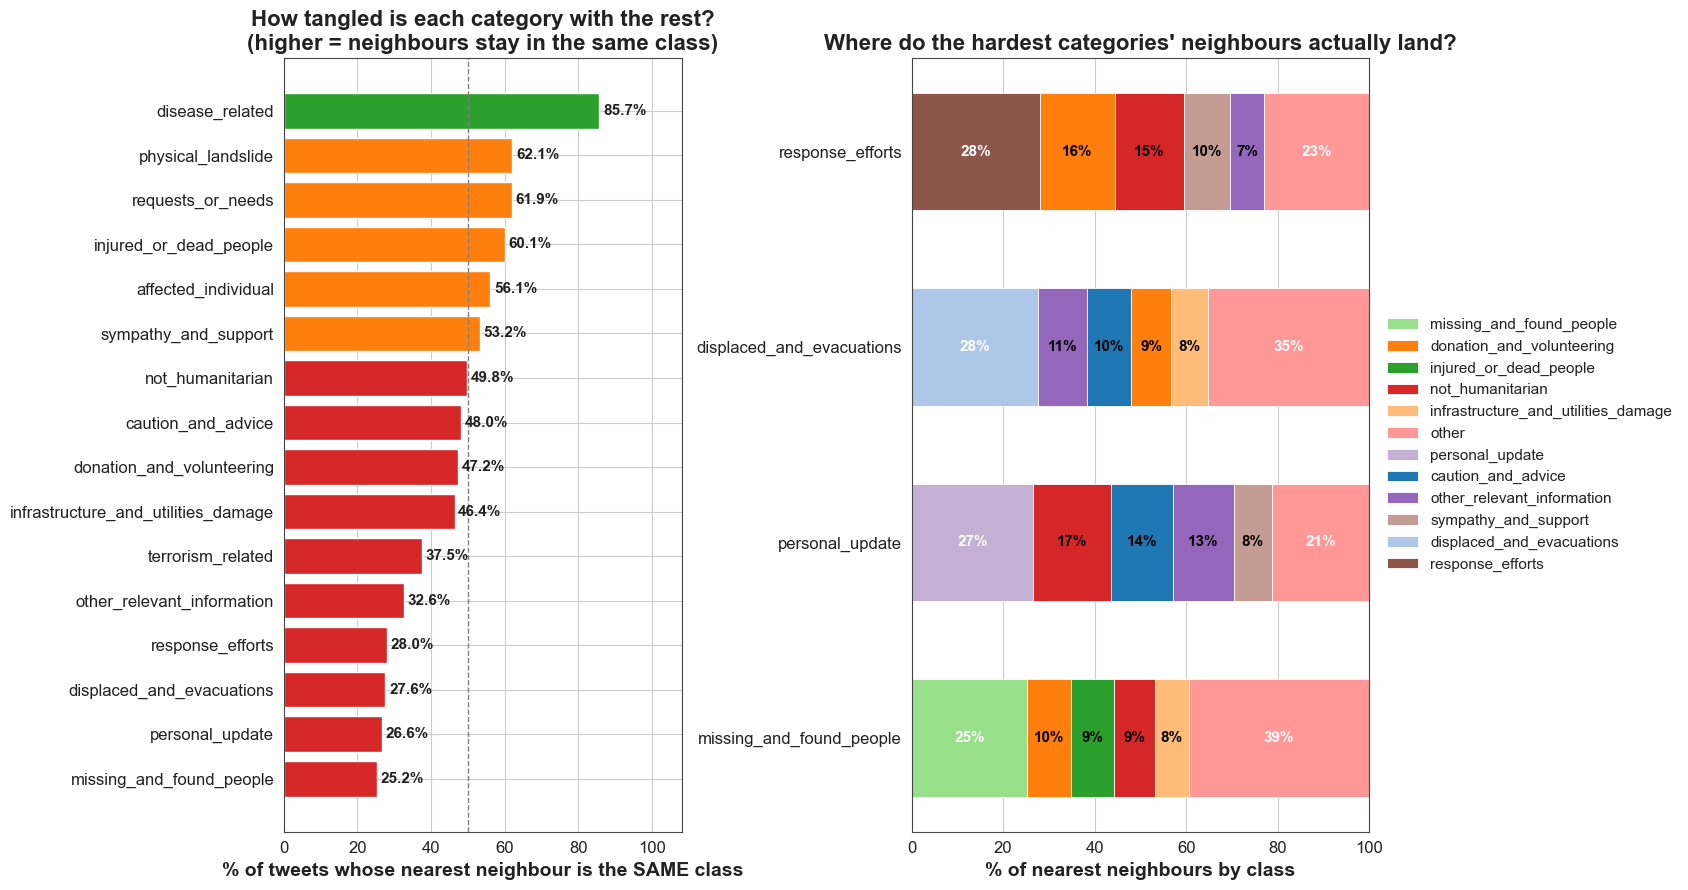


Same-class nearest-neighbour percentage per category (ascending — hardest first):
cls
missing_and_found_people               25.2
personal_update                        26.6
displaced_and_evacuations              27.6
response_efforts                       28.0
other_relevant_information             32.6
terrorism_related                      37.5
infrastructure_and_utilities_damage    46.4
donation_and_volunteering              47.2
caution_and_advice                     48.0
not_humanitarian                       49.8
sympathy_and_support                   53.2
affected_individual                    56.1
injured_or_dead_people                 60.1
requests_or_needs                      61.9
physical_landslide                     62.1
disease_related                        85.7


In [14]:
# NearestNeighbors — sklearn's index for k-nearest-neighbour search.
# We use cosine distance because TF-IDF vectors are compared by the angle
# between them (matches what TfidfVectorizer + linear models effectively do).
from sklearn.neighbors import NearestNeighbors

# Stratified subsample: up to SAMPLE_PER_CLASS tweets per class. Tiny
# classes are kept in full so the rare-class signal isn't lost. Without
# this cap, a brute-force pairwise cosine search on 130k+ vectors would
# take far too long for a notebook cell.
SAMPLE_PER_CLASS = 5000
rng = np.random.RandomState(42)

sample_idx = []
for label in df['class_label'].unique():
    cls_idx = df.index[df['class_label'] == label].to_numpy()
    if len(cls_idx) > SAMPLE_PER_CLASS:
        cls_idx = rng.choice(cls_idx, SAMPLE_PER_CLASS, replace=False)
    sample_idx.extend(cls_idx)
sample_idx = np.array(sample_idx)
print(f'Nearest-neighbour sample size: {len(sample_idx):,} tweets '
      f'(out of {len(df):,} total)')

# Slice the production-spec TF-IDF matrix from EDA 4 down to this sample.
X_sample = X_full[sample_idx]
y_sample = df['class_label'].to_numpy()[sample_idx]

# k=2 because the first neighbour of every point is the point itself
# (cosine distance 0). We want the SECOND result — the genuine nearest
# *other* tweet. n_jobs=-1 parallelises the search across all CPU cores.
nn = NearestNeighbors(n_neighbors=2, metric='cosine', n_jobs=-1)
nn.fit(X_sample)
_, neighbour_idx = nn.kneighbors(X_sample, return_distance=True)

# Index 0 is the tweet itself; index 1 is the nearest other tweet.
nearest          = neighbour_idx[:, 1]
neighbour_class  = y_sample[nearest]
same_class       = (neighbour_class == y_sample)

# Same-class neighbour percentage per category, ascending so the worst
# categories appear at the top of the bar chart.
per_class_same = (
    pd.DataFrame({'cls': y_sample, 'same': same_class})
      .groupby('cls')['same']
      .mean()
      .sort_values()
)

# For each category, the breakdown of where its nearest neighbours
# actually land (same class + each other class as a fraction of that
# category's tweets). We'll use this for the right-hand stacked bar.
neighbour_breakdown = (
    pd.crosstab(y_sample, neighbour_class, normalize='index')
)

# Two-panel figure.
fig, axes = plt.subplots(1, 2, figsize=(17, 9),
                         gridspec_kw={'width_ratios': [1, 1.15]})

# LEFT: same-class neighbour percentage per category.
ax = axes[0]
# Colour-code: red < 50% (heavily tangled), orange 50–70%, green >= 70%.
colors = ['#d62728' if v < 0.50
          else '#ff7f0e' if v < 0.70
          else '#2ca02c'
          for v in per_class_same.values]
bars = ax.barh(per_class_same.index, per_class_same.values * 100,
               color=colors)
for bar, v in zip(bars, per_class_same.values):
    ax.text(v * 100 + 1, bar.get_y() + bar.get_height() / 2,
            f'{v * 100:.1f}%', va='center',
            fontsize=11, fontweight='bold')
ax.axvline(50, color='grey', linestyle='--', linewidth=1)
ax.set_xlim(0, 108)
ax.set_xlabel('% of tweets whose nearest neighbour is the SAME class')
ax.set_title('How tangled is each category with the rest?\n'
             '(higher = neighbours stay in the same class)')

# RIGHT: stacked-bar breakdown for the 4 hardest categories.
ax = axes[1]
worst = per_class_same.head(4).index.tolist()

# Build a stable colour map across the union of neighbour classes shown.
top_neighbours_all = []
for cls in worst:
    parts = neighbour_breakdown.loc[cls].sort_values(ascending=False)
    # Keep top 5 and bucket the rest as "other" so the bar stays readable.
    head = parts.head(5)
    other = parts.iloc[5:].sum()
    if other > 0:
        head = pd.concat([head, pd.Series({'other': other})])
    top_neighbours_all.append(head)

neighbour_classes = sorted({n for parts in top_neighbours_all
                            for n in parts.index})
cmap = dict(zip(neighbour_classes,
                sns.color_palette('tab20', len(neighbour_classes))))

y_pos = np.arange(len(worst))
seen_in_legend = set()
for cls, parts, y in zip(worst, top_neighbours_all, y_pos):
    left = 0.0
    for n_cls, frac in parts.items():
        label = n_cls if n_cls not in seen_in_legend else None
        seen_in_legend.add(n_cls)
        ax.barh(y, frac * 100, left=left, height=0.6,
                color=cmap[n_cls], edgecolor='white', linewidth=0.6,
                label=label)
        # Annotate slices that are big enough to read.
        if frac >= 0.07:
            ax.text(left + frac * 50, y,
                    f'{frac * 100:.0f}%', ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if frac > 0.18 else 'black')
        left += frac * 100

ax.set_yticks(y_pos)
ax.set_yticklabels(worst)
ax.set_xlim(0, 100)
ax.set_xlabel('% of nearest neighbours by class')
ax.set_title("Where do the hardest categories' neighbours actually land?")
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda5_nearest_neighbour.png'),
            bbox_inches='tight')
plt.show()

print('\nSame-class nearest-neighbour percentage per category '
      '(ascending — hardest first):')
print((per_class_same * 100).round(1).to_string())

**Insight.** Same-class neighbour percentages spread across all three colour bands, and the result is more pessimistic than the typical "long tail" framing suggests:

- **Green (≥ 70%):** *only* `disease_related` (≈86%). Disease tweets use distinctive vocabulary (virus names, symptoms, outbreak terms) that doesn't show up elsewhere, so they cluster cleanly.
- **Orange (50–70%):** 5 classes — `physical_landslide` (≈62%), `requests_or_needs` (≈62%), `injured_or_dead_people` (≈60%), `affected_individual` (≈56%), `sympathy_and_support` (≈53%). Workable but tangled.
- **Red (< 50%):** **10 of the 16 classes** — `not_humanitarian` itself sits at ≈50%, `caution_and_advice` (≈48%), `donation_and_volunteering` (≈47%), `infrastructure_and_utilities_damage` (≈46%), `terrorism_related` (≈38%), `other_relevant_information` (≈33%), and the four worst — `response_efforts` (≈28%), `displaced_and_evacuations` (≈28%), `personal_update` (≈27%), `missing_and_found_people` (≈25%). For the majority of categories the most similar tweet is more often than not in a *different* class.

**Two surprises worth flagging:**

1. **`not_humanitarian` is barely above the red line (≈50%).** Despite dominating the dataset by raw count, individual `not_humanitarian` tweets are not strongly clustered — many are closer to `caution_and_advice` or `other_relevant_information` content than to each other. Class size does not buy clean separation.
2. **The off-diagonal leakage is *diffuse*, not paired.** Looking at the right-hand panel for the four hardest categories, the leakage is spread thinly across many siblings rather than concentrated on a single twin:
    - `missing_and_found_people` → `donation_and_volunteering` (≈10%), `injured_or_dead_people` (≈9%), `not_humanitarian` (≈9%), `infrastructure_and_utilities_damage` (≈8%) — no dominant twin.
    - `personal_update` → `not_humanitarian` (≈17%), `caution_and_advice` (≈14%), `other_relevant_information` (≈13%), `sympathy_and_support` (≈8%) — leaks predominantly into vague catch-all classes.
    - `displaced_and_evacuations` → `other_relevant_information` (≈11%), `caution_and_advice` (≈10%), `donation_and_volunteering` (≈9%), `infrastructure_and_utilities_damage` (≈8%).
    - `response_efforts` → `donation_and_volunteering` (≈16%), `not_humanitarian` (≈15%), `sympathy_and_support` (≈10%), `other_relevant_information` (≈8%).

A pattern jumps out: the truly hard categories all bleed primarily into the same handful of broad-vocabulary classes — `not_humanitarian`, `other_relevant_information`, `donation_and_volunteering`, `caution_and_advice`. These act as **gravitational sinks**: their vocabulary is wide and generic enough that almost any tweet has *something* in common with them. EDA 3 highlighted centroid-level twins like `requests_or_needs` ↔ `donation_and_volunteering`; the per-tweet view shows a different and uglier picture — the hardest classes don't have a single twin, they bleed into 4–5 broad classes at once. The model isn't being asked to make one clean binary call; it's being asked to pick the right answer out of a diffuse fog.

**Why this matters more than EDA 3:** EDA 3 measured similarity between class **centroids** — averages can be clean even when individual tweets sprawl. This EDA measures the actual sprawl. A class can have a tidy centroid yet have its individual tweets scattered across the feature space — EDA 3 calls it distinct, this EDA correctly flags it as tangled.

### Implication for algorithm choice

The question this EDA poses is: *"how does each algorithm behave when individual training examples within a class are scattered, and the class as a whole bleeds diffusely into 4–5 'gravitational sink' siblings?"*

1. **Linear SVM — at the top.** Margin maximisation is robust to *scattered-but-separable* class structure. Even when individual tweets from one class sit close to tweets from several others, SVM finds the boundary that's farthest from the closest mis-labelled neighbour — a max-margin hyperplane. Combined with `class_weight='balanced'`, this is the most direct mathematical match for what EDA 5 just described.
2. **Logistic Regression — close second.** L2 regularisation is the trick: when correlated features have ambiguous class signal (as they do for tweets near the gravitational sinks), L2 spreads weight rather than concentrating it on a few noisy features. The result is a smoother decision boundary that doesn't over-fit to individual scattered examples. Expect LR to track SVM with a small but consistent gap.
3. **Random Forest — third.** RF can in principle carve diffuse multi-class regions through deep tree paths, but each path needs many examples to be reliable. For the four worst classes (with only a few hundred tweets each and no dominant twin), trees will struggle to find a stable splitting pattern — different bootstrap samples will produce wildly different trees, and the majority vote will lean toward whichever gravitational-sink class shows up most often. This is the failure mode the right-hand panel literally illustrates.
4. **Naive Bayes — last.** NB is *blind* to per-tweet overlap. It only knows the class-conditional word distributions `P(word | class)`. When a class's tweets are scattered across feature space, those word distributions blur into the gravitational-sink classes. With no `class_weight` knob (EDA 1) and high vocabulary overlap (EDA 3) compounding here, NB will fail hardest on exactly the red-band categories.

This EDA's algorithm prediction is the strongest of the five — it directly forecasts that **macro F1 will rank: SVM > LR > RF > NB**.

**Modelling consequences:**

1. **Predicted F1 ranking for notebook 03:** `disease_related` should top the per-class F1 leaderboard. The four red worst-cases above should trail. With 10 of 16 classes in the red zone, expect a **large gap between weighted F1 and macro F1** — weighted F1 will be propped up by the bigger classes, but macro F1 will reveal that most of the smaller ones are genuinely hard.
2. **`class_weight='balanced'`** is essential — the red categories are typically also the smaller ones, so without weighting the model would simply ignore them.
3. **Confusion-matrix prediction:** the hottest off-diagonal cells will not be the centroid twins from EDA 3, but rather leakage from the small specific classes (`missing_and_found_people`, `personal_update`, `response_efforts`, `displaced_and_evacuations`) into the broad catch-all classes (`not_humanitarian`, `other_relevant_information`, `donation_and_volunteering`, `caution_and_advice`). Notebook 03 verifies this directly.

## Summary of EDA → modelling implications

- **Imbalance is severe (EDA 1).** Use weighted F1 as primary metric, macro F1 as secondary, per-class recall on critical categories as tiebreaker, and `class_weight='balanced'` for the linear and forest models. Plain accuracy is reported but never used for model selection.
- **Vocabulary signal is strong (EDA 2).** TF-IDF unigrams + bigrams should be enough — classical linear models will be competitive without word embeddings or neural nets. The flip side: vocabulary mismatch on a brand-new disaster is a real deployment risk.
- **Some class centroids overlap heavily (EDA 3).** `requests_or_needs` ↔ `donation_and_volunteering` and `injured_or_dead_people` ↔ `missing_and_found_people` are predicted off-diagonal hotspots in the confusion matrix.
- **The TF-IDF matrix is ≈99.9% empty (EDA 4).** The typical tweet activates only ≈8 of the 10,000 features. Linear models and Naive Bayes are fine with that; **Random Forest is structurally hurt** — at every split it samples ≈100 features and almost all of them will be zero. The pain is concentrated on **rare classes** (where macro F1 lives) — on the big classes RF stays competitive.
- **Individual tweets are tangled across classes (EDA 5).** Same-class nearest-neighbour percentage is the strongest single predictor of per-class F1. Only `disease_related` (≈86%) is genuinely clean; **10 of 16 classes sit below 50%**, including `not_humanitarian` itself (≈50%). Off-diagonal leakage is *diffuse*: the hardest classes don't bleed into a single twin but spread thinly into the broad-vocabulary "gravitational sinks" (`not_humanitarian`, `other_relevant_information`, `donation_and_volunteering`, `caution_and_advice`).

---

### Aggregate algorithm prediction — what the five EDAs collectively forecast

Each EDA gave its own ranking of the four candidate models. Combining them:

| EDA | Demoted by this EDA | Reason |
|---|---|---|
| 1 — Imbalance | **Naive Bayes** | No `class_weight='balanced'` knob |
| 2 — Vocabulary fingerprints | Random Forest (mild) | Tree splits don't aggregate fingerprint-strength linearly |
| 3 — Centroid overlap | **Naive Bayes** | Independence assumption fails on shared vocabulary |
| 4 — Sparsity | **Random Forest** | √d feature subsampling wastes ≈99% of split candidates |
| 5 — Per-tweet tangling | Naive Bayes, Random Forest | NB blind to per-tweet overlap; RF struggles on diffuse boundaries with few examples |

**Combined ranking (best → worst), as a falsifiable prediction for notebook 03:**

1. **Linear SVM** — wins on EDA 3 (margin maximisation) and ties for the lead on EDAs 1, 2, 4, 5. The most consistently top-ranked model across all five EDAs.
2. **Logistic Regression** — close second to SVM on every EDA. Tracks SVM with a small consistent gap.
3. **Random Forest** — penalised by EDA 4 (sparsity) and EDA 5 (diffuse boundaries on rare classes), but EDA 4 explicitly flags that the penalty bites on **rare classes**, not common ones. Expected outcome: **competitive on weighted F1, clearly behind on macro F1**.
4. **Naive Bayes** — penalised by three of the five EDAs (1, 3, 5) for separate structural reasons. Expected to be the worst overall, especially on macro F1.

**The metric where this prediction is sharpest is macro F1**, because that's where the structural weaknesses in NB (no class weighting) and RF (sparsity on rare classes) compound. We expect **SVM > LR > RF > NB on macro F1**. On weighted F1 the gap between SVM, LR, and RF should be smaller — RF may even tie or marginally edge out the linear models on the big-class-dominated metric.

Notebook 03 trains the four models, scores them, and revisits each of these predictions cell by cell.